# Arbol de Decision y Analisis de Componentes Principales (PCA)

Este notebook organiza y compara el rendimiento de un Arbol de Decision con y sin PCA (5 componentes) para clasificar el diagnostico de cancer.

**Estructura del Documento:**
1. **PCA (5 Componentes)**
   - Loadings (Grafica de barras)
   - Biplot (Observaciones y variables)
   - Scree Plot
2. **Modelado y Evaluacion**
   - Preparacion de datos, escalado y PCA
   - Ajuste de hiperparametros priorizando `Recall`
   - Comparacion de metricas (sin PCA vs con PCA)
3. **Matrices de Confusion**
   - Analisis de falsos positivos y falsos negativos
4. **Interpretabilidad**
   - Importancia de variables y visualizacion del arbol
5. **Conclusiones**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from IPython.display import Markdown, display
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [5]:
# Carga y limpieza de datos
df = pd.read_csv('Cancer_Data.csv')
if 'Unnamed: 32' in df.columns:
    df = df.drop('Unnamed: 32', axis=1)
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Limpiar nombres de columna: eliminar espacios y comillas dobles
df.columns = df.columns.str.strip().str.replace('\"', '')

# Limpiar y codificar la variable objetivo (M: 1, B: 0)
df['diagnosis'] = df['diagnosis'].astype(str).str.strip().str.upper()
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Split de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado (necesario para PCA; en arboles no es obligatorio, pero lo usamos para consistencia)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Datos cargados y escalados con exito.')

Datos cargados y escalados con exito.


---
## 1. PCA (5 Componentes)

In [6]:
# Aplicacion de PCA con 5 componentes
pca = PCA(n_components=5, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

### 1.1 Loadings (Grafica de Barras)
Analizamos que variables originales tienen mayor peso en las componentes principales.

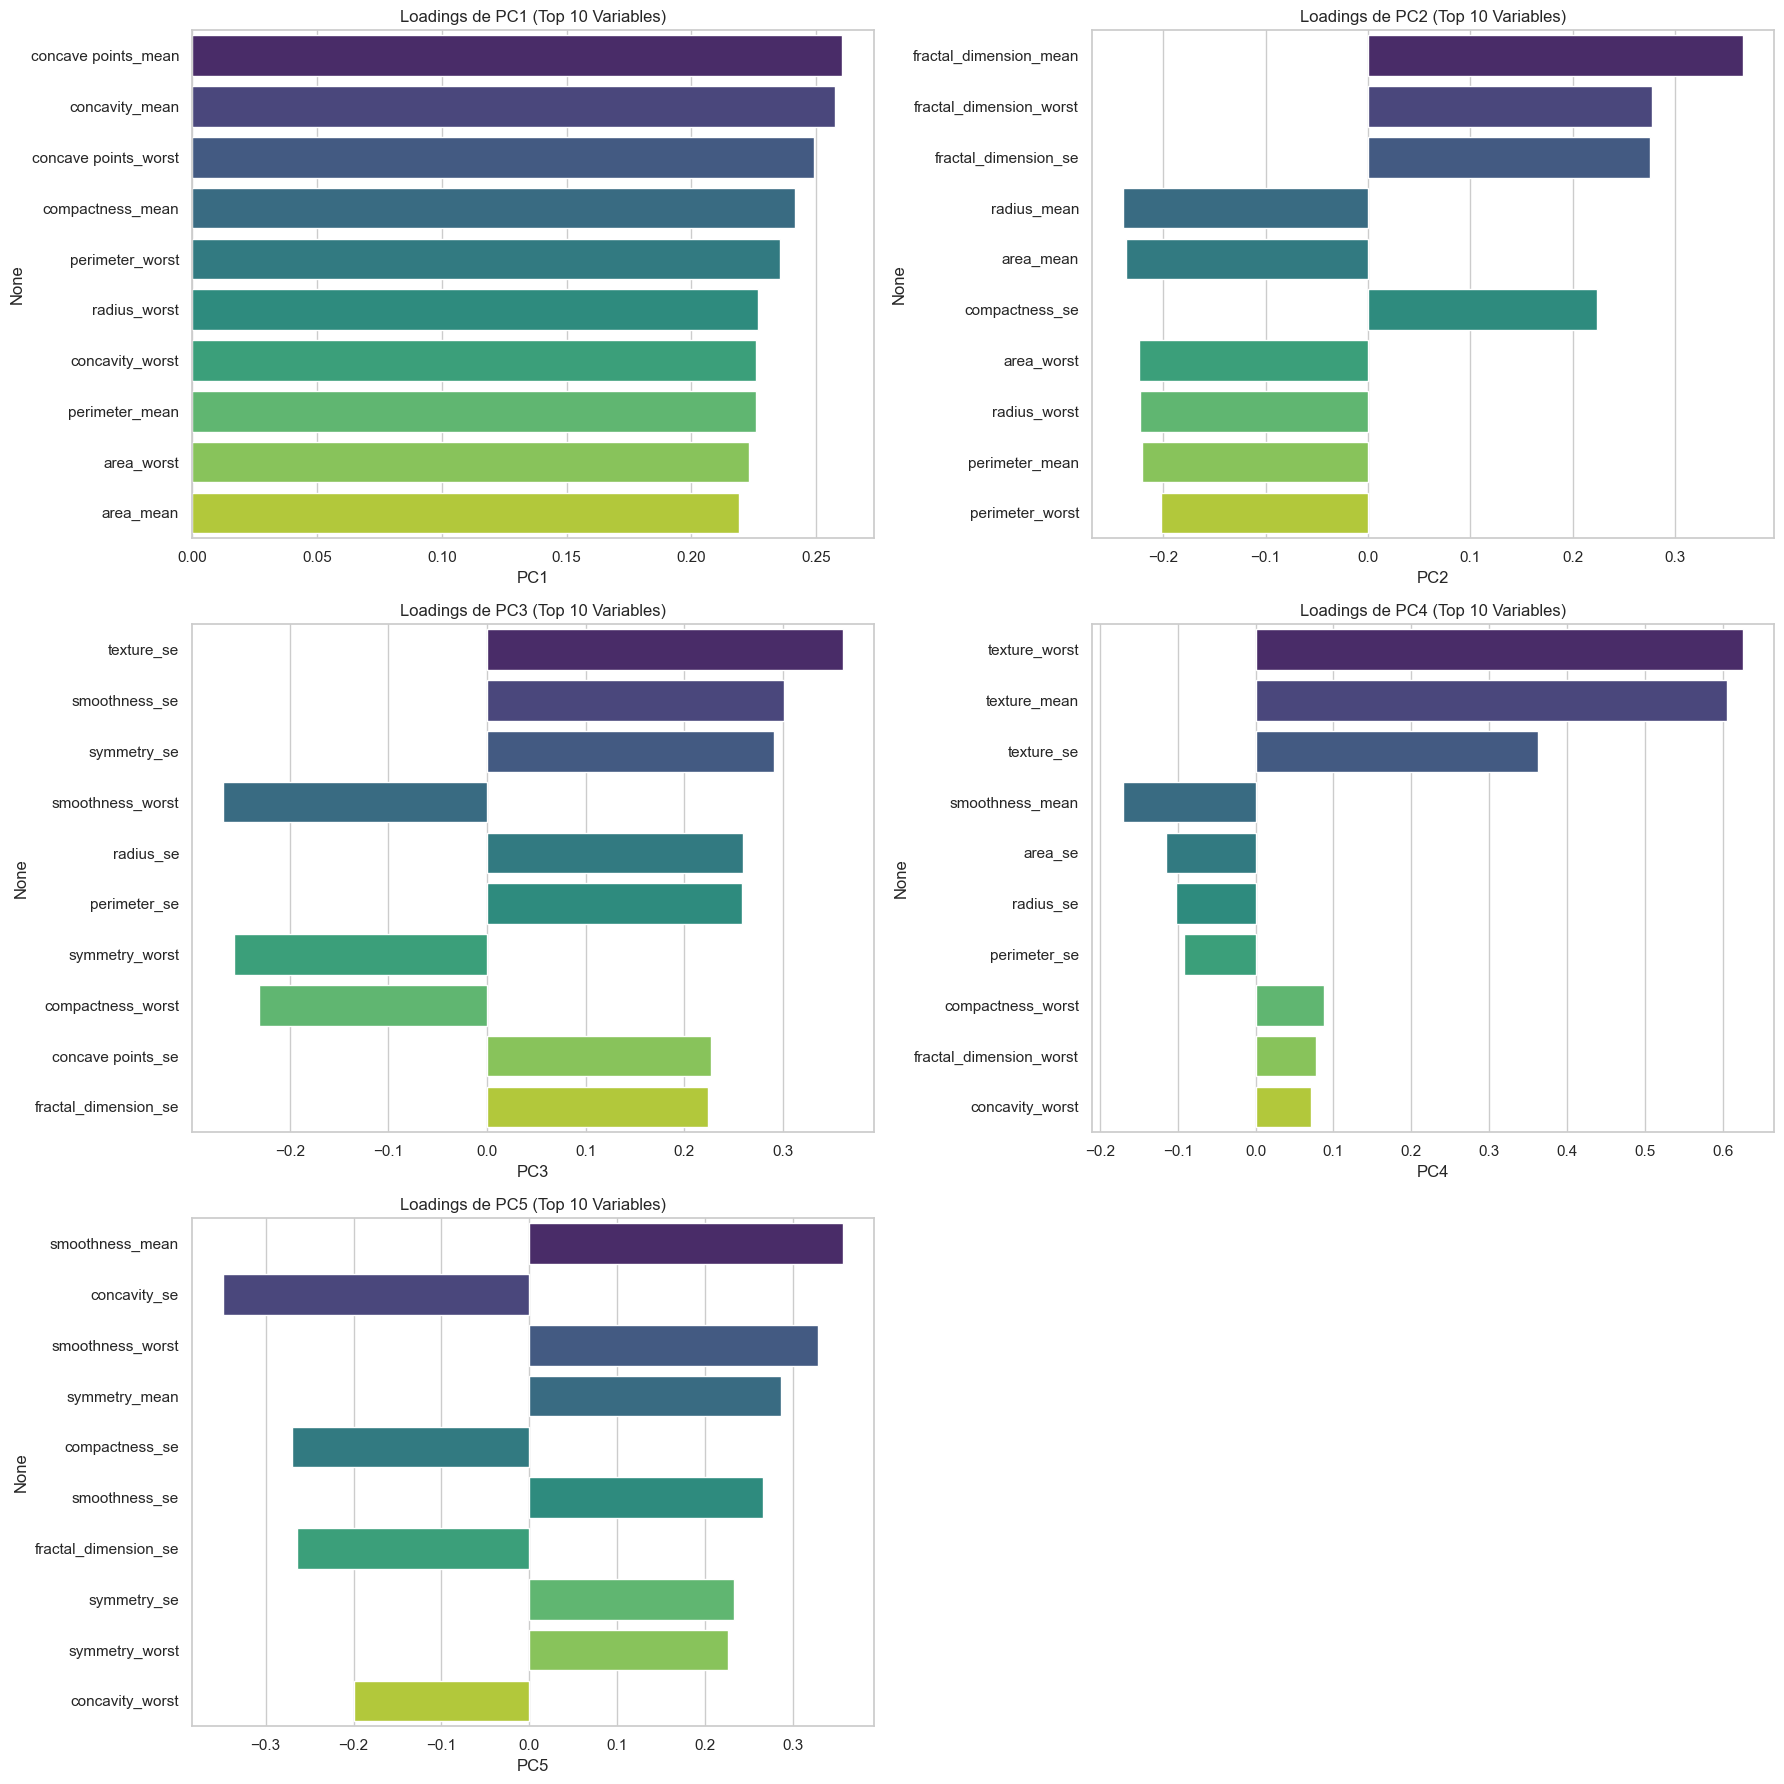

In [7]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(5)],
    index=X.columns
)

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for i in range(5):
    pc_name = f'PC{i+1}'
    top_pc_loadings = loadings[pc_name].abs().sort_values(ascending=False).head(10).index
    sns.barplot(
        x=loadings.loc[top_pc_loadings, pc_name],
        y=top_pc_loadings,
        palette='viridis',
        ax=axes[i]
    )
    axes[i].set_title(f'Loadings de {pc_name} (Top 10 Variables)')

if len(axes) > 5:
    fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

### 1.2 Biplot
Proyectamos observaciones y variables en el espacio de PC1 vs PC2.

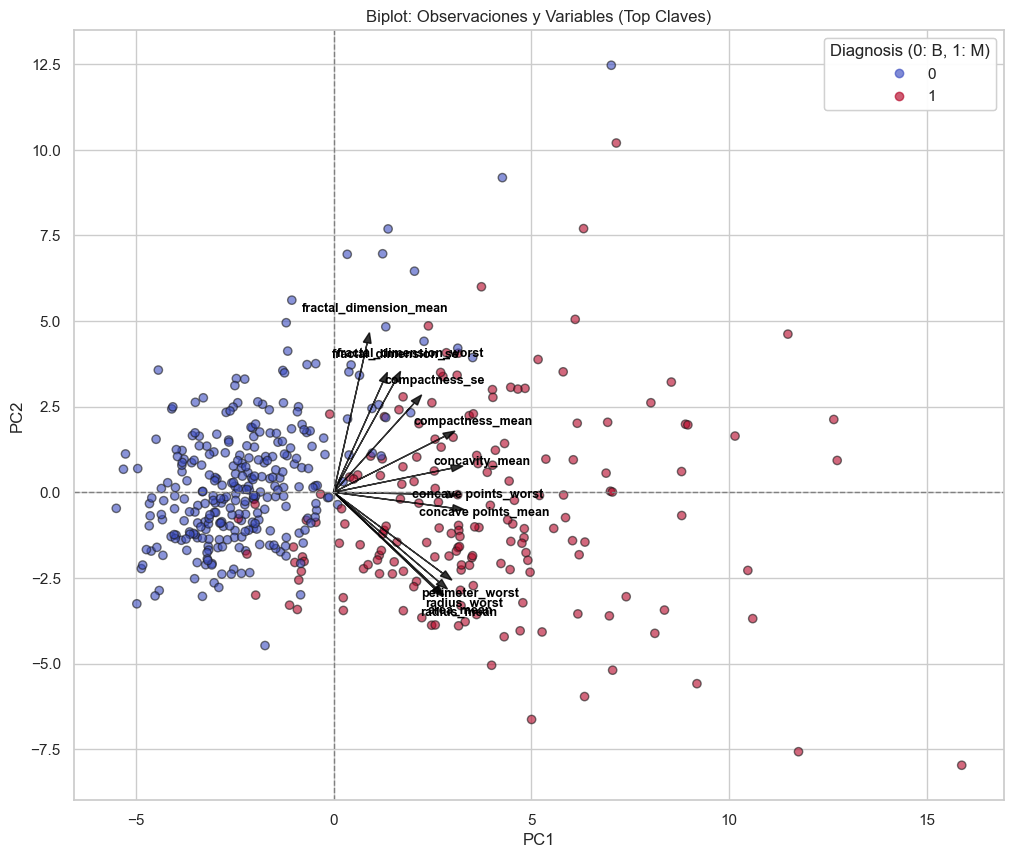

In [8]:
def biplot(score, coeff, labels=None):
    fig, ax = plt.subplots(figsize=(12, 10))
    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0]

    scatter = ax.scatter(xs, ys, c=y_train, cmap='coolwarm', alpha=0.6, edgecolors='k')
    legend = ax.legend(*scatter.legend_elements(), title='Diagnosis (0: B, 1: M)')
    ax.add_artist(legend)

    arrow_multiplier = max(xs.max(), ys.max()) * 0.8

    for i in range(n):
        ax.arrow(
            0, 0,
            coeff[i, 0] * arrow_multiplier,
            coeff[i, 1] * arrow_multiplier,
            color='black', alpha=0.8, head_width=0.2, length_includes_head=True
        )
        if labels is not None:
            ax.text(
                coeff[i, 0] * arrow_multiplier * 1.15,
                coeff[i, 1] * arrow_multiplier * 1.15,
                labels[i], color='black', ha='center', va='center', fontsize=9, fontweight='bold'
            )

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('Biplot: Observaciones y Variables (Top Claves)')
    plt.grid(True)
    plt.axhline(0, color='grey', linestyle='--', linewidth=1)
    plt.axvline(0, color='grey', linestyle='--', linewidth=1)
    plt.show()

top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(6).index
top_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(6).index
top_vars = list(set(top_pc1).union(set(top_pc2)))
coeff_subset = pca.components_.T[X.columns.get_indexer(top_vars)]

biplot(X_train_pca, coeff_subset, labels=top_vars)

### 1.3 Scree Plot
Graficamos la varianza explicada por cada una de las 5 componentes y su varianza acumulada.

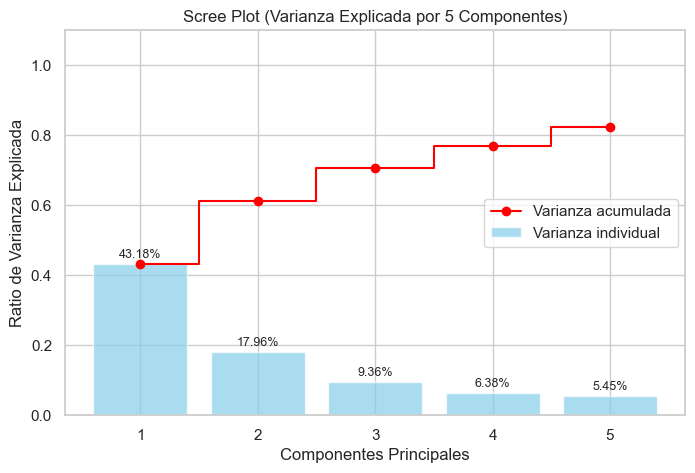

In [9]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
bars = plt.bar(range(1, 6), explained_variance, alpha=0.7, align='center', label='Varianza individual', color='skyblue')
plt.step(range(1, 6), cumulative_variance, where='mid', label='Varianza acumulada', color='red', marker='o')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.01, f'{yval:.2%}', ha='center', va='bottom', fontsize=9)

plt.ylabel('Ratio de Varianza Explicada')
plt.xlabel('Componentes Principales')
plt.xticks(range(1, 6))
plt.title('Scree Plot (Varianza Explicada por 5 Componentes)')
plt.legend(loc='center right')
plt.ylim(0, 1.1)
plt.show()

---
## 2. Modelado y Evaluacion
Ajustamos hiperparametros priorizando **Recall** (evitar falsos negativos). Despues revisamos el **F1-Score** como balance entre precision y recall.

In [10]:
def evaluar_modelo(nombre_modelo, y_true, y_pred):
    return {
        'Modelo': nombre_modelo,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

def entrenar_y_predecir(modelo, X_tr, X_te, y_tr):
    modelo.fit(X_tr, y_tr)
    return modelo.predict(X_te)

def seleccionar_mejor(df):
    return df.sort_values(by=['Recall', 'F1-Score', 'Accuracy'], ascending=False).iloc[0]

In [11]:
param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

resultados_sin_pca = []
resultados_con_pca = []

for max_depth in param_grid['max_depth']:
    for min_samples_split in param_grid['min_samples_split']:
        for min_samples_leaf in param_grid['min_samples_leaf']:
            params = {
                'max_depth': max_depth,
                'min_samples_split': min_samples_split,
                'min_samples_leaf': min_samples_leaf,
                'random_state': 42
            }

            dt_sin = DecisionTreeClassifier(**params)
            pred_sin = entrenar_y_predecir(dt_sin, X_train, X_test, y_train)
            met_sin = evaluar_modelo('Arbol sin PCA', y_test, pred_sin)
            met_sin.update(params)
            resultados_sin_pca.append(met_sin)

            dt_con = DecisionTreeClassifier(**params)
            pred_con = entrenar_y_predecir(dt_con, X_train_pca, X_test_pca, y_train)
            met_con = evaluar_modelo('Arbol con PCA', y_test, pred_con)
            met_con.update(params)
            resultados_con_pca.append(met_con)

df_sin = pd.DataFrame(resultados_sin_pca)
df_con = pd.DataFrame(resultados_con_pca)

In [12]:
df_sin_orden = df_sin.sort_values(by=['Recall', 'F1-Score', 'Accuracy'], ascending=False)
df_con_orden = df_con.sort_values(by=['Recall', 'F1-Score', 'Accuracy'], ascending=False)

best_sin = seleccionar_mejor(df_sin)
best_con = seleccionar_mejor(df_con)

display(df_sin_orden.head(5))
display(df_con_orden.head(5))

,Modelo,Accuracy,Precision,Recall,F1-Score,max_depth,min_samples_split,min_samples_leaf,random_state
18,Arbol sin PCA,0.938596,0.926829,0.904762,0.915663,7.0,2,1,42
27,Arbol sin PCA,0.921053,0.902439,0.880952,0.891566,NaN,2,1,42
28,Arbol sin PCA,0.929825,0.947368,0.857143,0.900000,NaN,2,2,42
21,Arbol sin PCA,0.921053,0.923077,0.857143,0.888889,7.0,5,1,42
30,Arbol sin PCA,0.921053,0.923077,0.857143,0.888889,NaN,5,1,42


,Modelo,Accuracy,Precision,Recall,F1-Score,max_depth,min_samples_split,min_samples_leaf,random_state
19,Arbol con PCA,0.956140,0.951220,0.928571,0.939759,7.0,2,2,42
28,Arbol con PCA,0.947368,0.928571,0.928571,0.928571,NaN,2,2,42
10,Arbol con PCA,0.947368,0.950000,0.904762,0.926829,5.0,2,2,42
0,Arbol con PCA,0.912281,0.863636,0.904762,0.883721,3.0,2,1,42
1,Arbol con PCA,0.912281,0.863636,0.904762,0.883721,3.0,2,2,42


In [13]:
def normalizar_max_depth(valor):
    return None if pd.isna(valor) else int(valor)

best_params_sin = {
    'max_depth': normalizar_max_depth(best_sin['max_depth']),
    'min_samples_split': int(best_sin['min_samples_split']),
    'min_samples_leaf': int(best_sin['min_samples_leaf']),
    'random_state': 42
}
best_params_con = {
    'max_depth': normalizar_max_depth(best_con['max_depth']),
    'min_samples_split': int(best_con['min_samples_split']),
    'min_samples_leaf': int(best_con['min_samples_leaf']),
    'random_state': 42
}

dt_best_sin = DecisionTreeClassifier(**best_params_sin)
dt_best_con = DecisionTreeClassifier(**best_params_con)

pred_best_sin = entrenar_y_predecir(dt_best_sin, X_train, X_test, y_train)
pred_best_con = entrenar_y_predecir(dt_best_con, X_train_pca, X_test_pca, y_train)

resumen_metricas = pd.DataFrame([
    evaluar_modelo('Arbol sin PCA', y_test, pred_best_sin),
    evaluar_modelo('Arbol con PCA (5 comp)', y_test, pred_best_con)
])

display(resumen_metricas)

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Arbol sin PCA,0.938596,0.926829,0.904762,0.915663
1,Arbol con PCA (5 comp),0.956140,0.951220,0.928571,0.939759


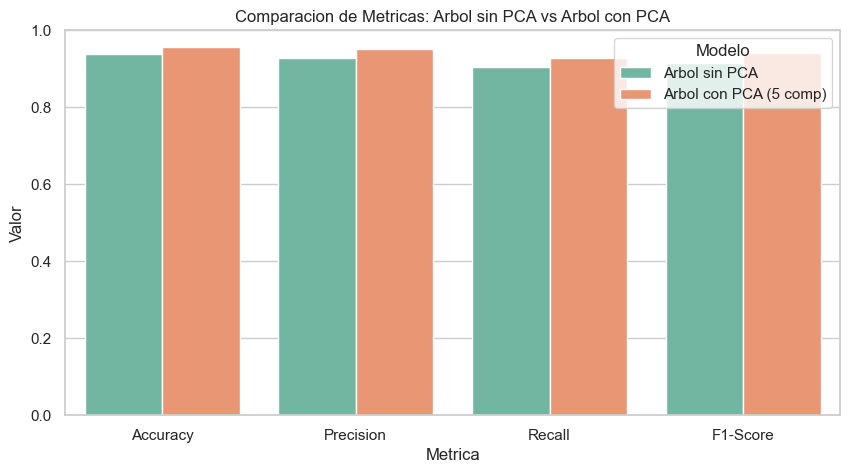

In [14]:
resumen_melt = resumen_metricas.melt(id_vars='Modelo', var_name='Metrica', value_name='Valor')
plt.figure(figsize=(10, 5))
sns.barplot(data=resumen_melt, x='Metrica', y='Valor', hue='Modelo', palette='Set2')
plt.ylim(0, 1)
plt.title('Comparacion de Metricas: Arbol sin PCA vs Arbol con PCA')
plt.show()

---
## 3. Matrices de Confusion
Analizamos falsos positivos y falsos negativos, con enfasis en los falsos negativos por su impacto medico.

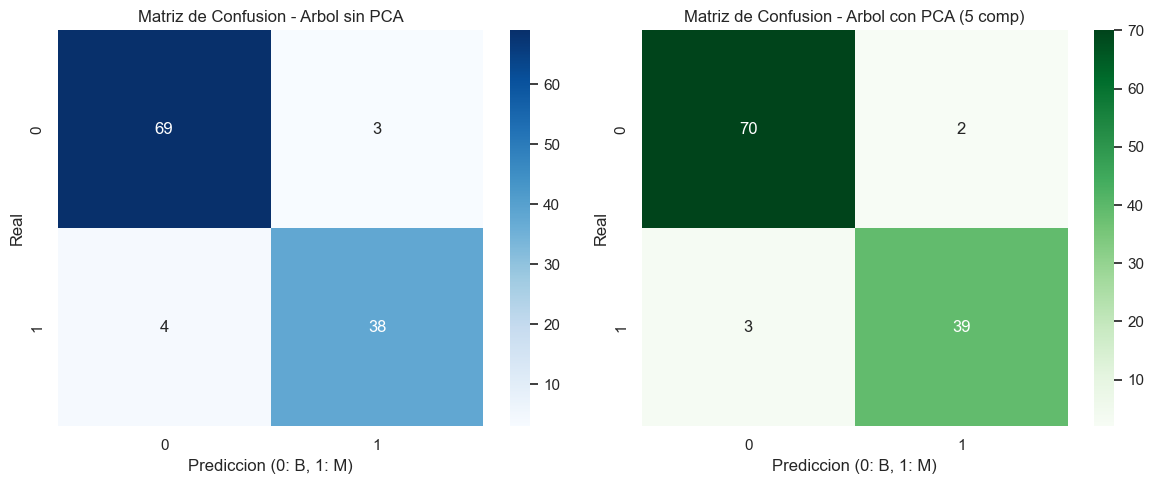

Falsos Negativos (Maligno clasificado como Benigno):
 - Sin PCA: 4
 - Con PCA: 3
Falsos Positivos (Benigno clasificado como Maligno):
 - Sin PCA: 3
 - Con PCA: 2


In [15]:
cm_sin = confusion_matrix(y_test, pred_best_sin)
cm_con = confusion_matrix(y_test, pred_best_con)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_sin, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusion - Arbol sin PCA')
axes[0].set_xlabel('Prediccion (0: B, 1: M)')
axes[0].set_ylabel('Real')

sns.heatmap(cm_con, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Matriz de Confusion - Arbol con PCA (5 comp)')
axes[1].set_xlabel('Prediccion (0: B, 1: M)')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

fn_sin = cm_sin[1, 0]
fp_sin = cm_sin[0, 1]
fn_con = cm_con[1, 0]
fp_con = cm_con[0, 1]

print('Falsos Negativos (Maligno clasificado como Benigno):')
print(f' - Sin PCA: {fn_sin}')
print(f' - Con PCA: {fn_con}')
print('Falsos Positivos (Benigno clasificado como Maligno):')
print(f' - Sin PCA: {fp_sin}')
print(f' - Con PCA: {fp_con}')

---
## 4. Interpretabilidad
El Arbol de Decision es mas interpretable que KNN porque se puede visualizar y explicar mediante reglas. Con PCA, la interpretabilidad baja porque las componentes principales son combinaciones de variables originales.

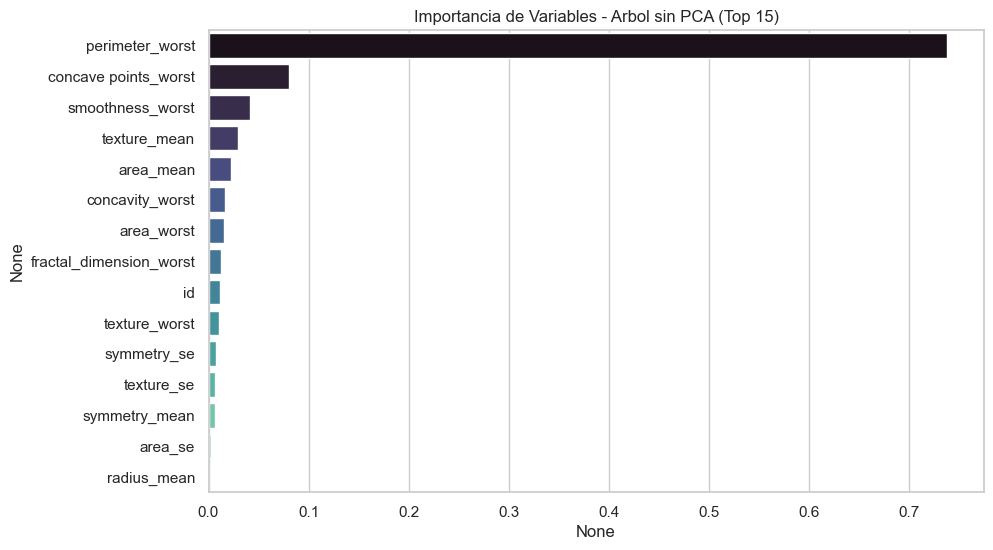

In [16]:
importancias = pd.Series(dt_best_sin.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importancias.head(15), y=importancias.head(15).index, palette='mako')
plt.title('Importancia de Variables - Arbol sin PCA (Top 15)')
plt.show()

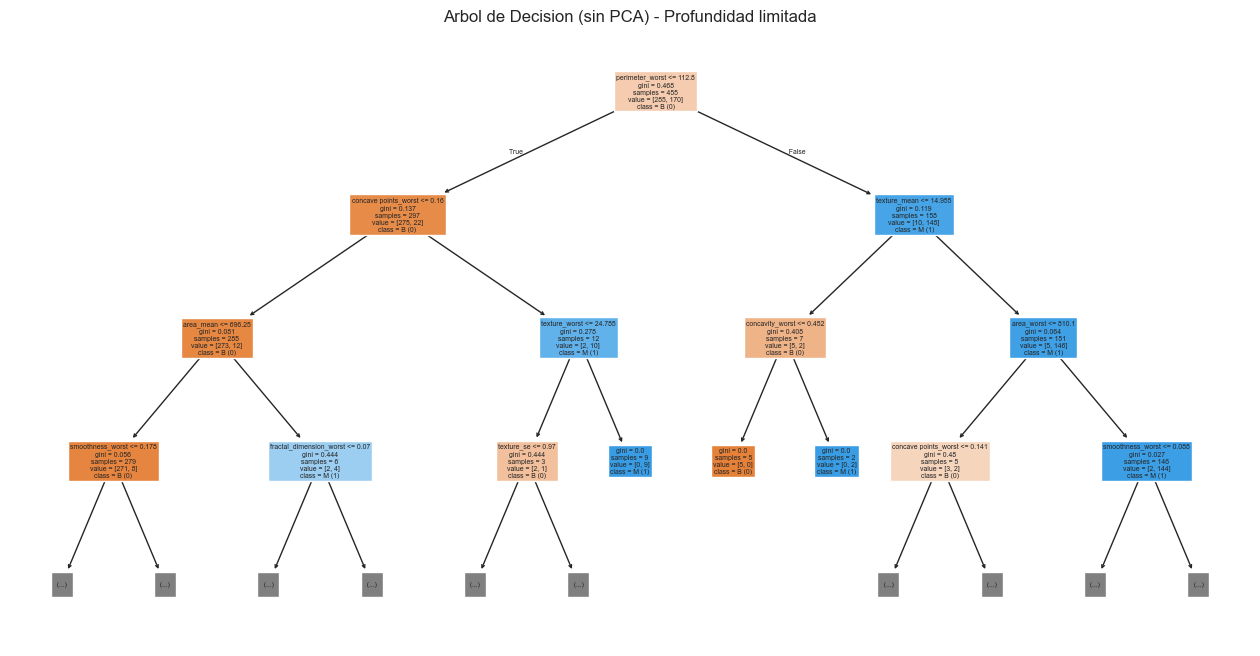

In [17]:
plt.figure(figsize=(16, 8))
plot_tree(
    dt_best_sin,
    feature_names=X.columns,
    class_names=['B (0)', 'M (1)'],
    filled=True,
    max_depth=3
)
plt.title('Arbol de Decision (sin PCA) - Profundidad limitada')
plt.show()

---
## 5. Conclusiones
En esta seccion se resume el modelo con mejor recall, el mejor F1-Score y el balance entre rendimiento e interpretabilidad.

In [18]:
recall_sin = resumen_metricas.loc[resumen_metricas['Modelo'] == 'Arbol sin PCA', 'Recall'].values[0]
recall_con = resumen_metricas.loc[resumen_metricas['Modelo'] == 'Arbol con PCA (5 comp)', 'Recall'].values[0]
f1_sin = resumen_metricas.loc[resumen_metricas['Modelo'] == 'Arbol sin PCA', 'F1-Score'].values[0]
f1_con = resumen_metricas.loc[resumen_metricas['Modelo'] == 'Arbol con PCA (5 comp)', 'F1-Score'].values[0]

mejor_recall = 'Arbol sin PCA' if recall_sin >= recall_con else 'Arbol con PCA (5 comp)'
mejor_f1 = 'Arbol sin PCA' if f1_sin >= f1_con else 'Arbol con PCA (5 comp)'

conclusion_lines = [
    '### Conclusiones Interpretativas',
    f'- **Mejor Recall:** {mejor_recall} (sin PCA: {recall_sin:.3f}, con PCA: {recall_con:.3f}).',
    f'- **Mejor F1-Score:** {mejor_f1} (sin PCA: {f1_sin:.3f}, con PCA: {f1_con:.3f}).',
    '- **PCA vs Sin PCA:** PCA puede reducir dimensionalidad y mejorar generalizacion, pero pierde interpretabilidad directa.',
    '- **Interpretabilidad:** El arbol sin PCA permite reglas claras y variables originales, lo cual es crucial en contexto medico.',
    '- **Recomendacion:** Priorizar el modelo con mejor recall. Si ambos son similares, elegir el sin PCA por su interpretabilidad.'
]

display(Markdown('\n'.join(conclusion_lines)))

### Conclusiones Interpretativas
- **Mejor Recall:** Arbol con PCA (5 comp) (sin PCA: 0.905, con PCA: 0.929).
- **Mejor F1-Score:** Arbol con PCA (5 comp) (sin PCA: 0.916, con PCA: 0.940).
- **PCA vs Sin PCA:** PCA puede reducir dimensionalidad y mejorar generalizacion, pero pierde interpretabilidad directa.
- **Interpretabilidad:** El arbol sin PCA permite reglas claras y variables originales, lo cual es crucial en contexto medico.
- **Recomendacion:** Priorizar el modelo con mejor recall. Si ambos son similares, elegir el sin PCA por su interpretabilidad.